In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))

def print_wlexpr_latex(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    print(tex_expr)
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    img = mpimg.imread(filename)
    imgplot = plt.imshow(img)
    plt.show()
    plt.axis('off')

## Sine Integral - Odd Powers

In [4]:
wc('''
indefsinintodd = 1/Pi*Integrate[Sin[n*t]*Sin[t]^(2*m+1), t]
''')

<IPython.core.display.Math object>

Times[Complex[0, -1], Power[4, Plus[-1, Times[-1, Global`m]]], << 5 >>, Power[Pi, -1], Plus[Times[Plus[1, Times[2, Global`m], Times[-1, Global`n]], Hypergeometric2F1[Plus[-1, Times[-2, Global`m]], Plus[Rational[-1, 2], Times[-1, Global`m], Times[Rational[-1, 2], Global`n]], Plus[Rational[1, 2], Times[-1, Global`m], Times[Rational[-1, 2], Global`n]], Power[E, Times[Complex[0, 2], Global`t]]]], Times[-1, Power[E, Times[Complex[0, 2], Global`n, Global`t]], Plus[1, Times[2, Global`m], Global`n], Hypergeometric2F1[Plus[-1, Times[-2, Global`m]], Times[Rational[1, 2], Plus[-1, Times[-2, Global`m], Global`n]], Times[Rational[1, 2], Plus[1, Times[-2, Global`m], Global`n]], Power[E, Times[Complex[0, 2], Global`t]]]]]]

In [5]:
wc('''
defsinintodd = FullSimplify[
   (indefsinintodd /. t -> Pi) - (indefsinintodd /. t -> 0)
]
''')

<IPython.core.display.Math object>

Times[Complex[0, 1], Power[2, Plus[-3, Times[-2, Global`m]]], << 4 >>, Power[Gamma[Plus[Rational[3, 2], Global`m, Times[Rational[1, 2], Global`n]]], -1], Plus[Sec[Times[Rational[1, 2], Plus[Times[2, Global`m], Global`n], Pi]], Times[-1, Power[E, Times[Complex[0, 1], Global`n, Pi]], Sec[Plus[Times[Global`m, Pi], Times[Rational[-1, 2], Global`n, Pi]]]]]]

In [6]:
wc('''
Denominator[
    Limit[FullSimplify[defsinintodd /. m -> Range[10]], n-> 3]
]
''')

<IPython.core.display.Math object>

(8, 32, 128, 128, 1024, 8192, 32768, 16384, 262144, 1048576)

In [7]:
wc('''
Numerator[
    Limit[FullSimplify[defsinintodd /. m -> Range[10]], n-> 3]
]
''')

<IPython.core.display.Math object>

(1, -5, 21, -21, 165, -1287, 5005, -2431, 37791, -146965)

In [8]:
wc('''
FullSimplify[defsinintodd]
''')

<IPython.core.display.Math object>

Times[Complex[0, 1], Power[2, Plus[-3, Times[-2, Global`m]]], << 4 >>, Power[Gamma[Plus[Rational[3, 2], Global`m, Times[Rational[1, 2], Global`n]]], -1], Plus[Sec[Times[Rational[1, 2], Plus[Times[2, Global`m], Global`n], Pi]], Times[-1, Power[E, Times[Complex[0, 1], Global`n, Pi]], Sec[Plus[Times[Global`m, Pi], Times[Rational[-1, 2], Global`n, Pi]]]]]]

In [9]:
# Simplify the complex part
wc('''
FullSimplify[
   (I*Exp[-I*Pi*n]*(1 + Exp[I*Pi*n])*(Sec[Pi*m + Pi*n/2] - Exp[I*Pi*n]*Sec[Pi*m - Pi*n/2]) ),
   Assumptions -> {Element[m, Integers]}
]
''')

<IPython.core.display.Math object>

Times[4, Power[-1, Global`m], Sin[Times[Rational[1, 2], Global`n, Pi]]]

In [10]:
# Simplify the pure real part
wc('''
FullSimplify[
2^(-2*m-3) * Gamma[2*m+2] / (Gamma[m - n/2 + 3/2] * Gamma[m+n/2+3/2]) /. n -> {1,3,5}
]''')

<IPython.core.display.Math object>

(Times[Rational[1, 4], Power[Pi, Rational[-1, 2]], Gamma[Plus[Rational[3, 2], Global`m]], Power[Gamma[Plus[2, Global`m]], -1]],
 Times[Power[2, Plus[-3, Times[-2, Global`m]]], Power[Gamma[Global`m], -1], Power[Gamma[Plus[3, Global`m]], -1], Gamma[Plus[2, Times[2, Global`m]]]],
 Times[Power[2, Plus[-3, Times[-2, Global`m]]], Power[Gamma[Plus[-1, Global`m]], -1], Power[Gamma[Plus[4, Global`m]], -1], Gamma[Plus[2, Times[2, Global`m]]]])

In [11]:
# Test the nth term formula
wc('''
4*(-1)^m * I^(n-1)*Factorial[2*m+1] / (2^(2*m+3) * Factorial[m-1] * Factorial[m+2]) /. n->3 /. m -> Range[10]
''')

<IPython.core.display.Math object>

(Rational[1, 8],
 Rational[-5, 32],
 Rational[21, 128],
 Rational[-21, 128],
 Rational[165, 1024],
 Rational[-1287, 8192],
 Rational[5005, 32768],
 Rational[-2431, 16384],
 Rational[37791, 262144],
 Rational[-146965, 1048576])

In [12]:
wc('''
(4*(-1)^m * I^(n-1)*Factorial[2*m+1] / (Factorial[m-1]*Factorial[m+2])) /. n->7 /. m -> Range[10]
''')

<IPython.core.display.Math object>

(4, -20, 84, -336, 1320, -5148, 20020, -77792, 302328, -1175720)

In [13]:
wc('''
FullSimplify[
(2^(2*m+3)) /. n->5 /. m -> Range[10]
]''')

<IPython.core.display.Math object>

(32, 128, 512, 2048, 8192, 32768, 131072, 524288, 2097152, 8388608)

In [14]:
wc('''
(Factorial[2*m+1] / (Factorial[m-1]*Factorial[m+2])) /. m -> Range[10]
''')

<IPython.core.display.Math object>

(1, 5, 21, 84, 330, 1287, 5005, 19448, 75582, 293930)

In [30]:
# Test a better nth term formula
wc('''
(-1)^m * (-1)^((n-1)/2) * (2*m+1)! / (2^(2*m+1) * (m - (n-1)/2)! * (m + (n+1)/2)!) /. n-> 3 /. m -> Range[10]
''')

<IPython.core.display.Math object>

(Rational[1, 8],
 Rational[-5, 32],
 Rational[21, 128],
 Rational[-21, 128],
 Rational[165, 1024],
 Rational[-1287, 8192],
 Rational[5005, 32768],
 Rational[-2431, 16384],
 Rational[37791, 262144],
 Rational[-146965, 1048576])

In [21]:
wc('''
(2*m+1)! / ((m-(n-1)/2)!*(m+(n+1)/2)!) /. n-> 5 /. m -> Range[10]
''')

<IPython.core.display.Math object>

(0, 1, 7, 36, 165, 715, 3003, 12376, 50388, 203490)

In [28]:
wc('''
FullSimplify[(2*m+1)! / ((m-(n-1)/2)!*(m+(n+1)/2)!) - Binomial[2*m+1, m - (n-1)/2], Assumptions -> {Element[m, Integers]}]
''')

<IPython.core.display.Math object>

0

In [32]:
# Test an even better nth term formula
wc('''
(-1)^m * (-1)^((n-1)/2) / (2^(2*m+1)) * Binomial[2*m+1, m - (n-1)/2] /. n-> 3 /. m -> Range[10]
''')

<IPython.core.display.Math object>

(Rational[1, 8],
 Rational[-5, 32],
 Rational[21, 128],
 Rational[-21, 128],
 Rational[165, 1024],
 Rational[-1287, 8192],
 Rational[5005, 32768],
 Rational[-2431, 16384],
 Rational[37791, 262144],
 Rational[-146965, 1048576])

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


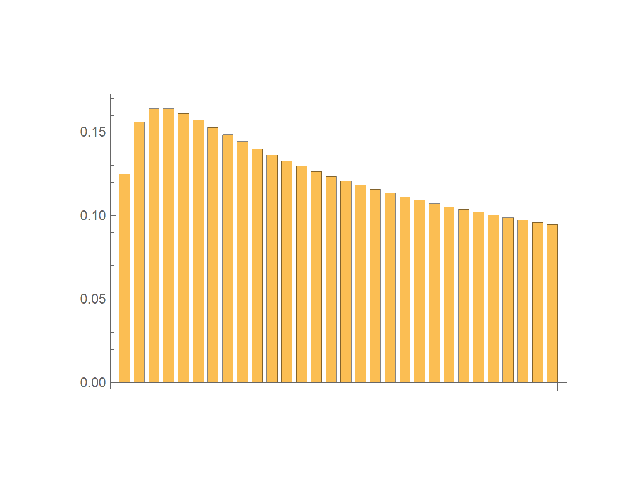

In [36]:
wplot('figure.png',
'''
BarChart[
Abs[(-1)^m * (-1)^((n-1)/2) / (2^(2*m+1)) * Binomial[2*m+1, m - (n-1)/2] /. n-> 3 /. m -> Range[30]]
]
''')

## Sine Integral - Even Powers

In [ ]:
wc('''
indefsininteven = 1/Pi*Integrate[Sin[n*t]*Sin[t]^(2*m), t]
''')

In [ ]:
wc('''
defsininteven = FullSimplify[
   (indefsininteven /. t -> Pi) - (indefsininteven /. t -> 0)
]
''')

In [ ]:
wc('''
Abs[Numerator[
    Limit[FullSimplify[(defsininteven /. m -> Range[10])], n-> 1]
]]
''')

In [ ]:
wc('''
Abs[Denominator[
    Limit[FullSimplify[(defsininteven*Pi /. m -> Range[10])], n-> 1]
]]
''')

## Sine Integral - Both

In [ ]:
wc('''
indefsinint = Integrate[Sin[n*t]*Sin[t]^(m), t]
''')

In [ ]:
wc('''
defsinint = FullSimplify[
   (indefsinint /. t -> Pi) - (indefsinint /. t -> 0)
]
''')

In [ ]:
wc('''
Abs[Numerator[
    Limit[FullSimplify[(defsinint /. m -> Range[20])/Pi], n-> 1]
]]
''')

In [ ]:
wc('''
Abs[Denominator[
    Limit[FullSimplify[(defsinint /. m -> Range[20])], n-> 1]
]]
''')

## Cosine Integral - Odd Powers

In [ ]:
wc('''
indefcosintodd = 1/Pi*Integrate[Cos[n*t]*Sin[t]^(2*m+1), t]
''')

In [ ]:
wc('''
defcosintodd = FullSimplify[
   (indefcosintodd /. t -> Pi) - (indefcosintodd /. t -> 0)
]
''')

In [ ]:
wc('''
Abs[Numerator[
    Limit[FullSimplify[defcosintodd /. m -> Range[10]], n-> 1]
]]
''')

In [ ]:
wc('''
Abs[Denominator[
    Limit[FullSimplify[defcosintodd /. m -> Range[10]], n-> 1]
]]
''')

## Cosine Integral - Even Powers

In [ ]:
wc('''
indefcosinteven = 1/Pi*Integrate[Cos[n*t]*Sin[t]^(2*m), t]
''')

In [ ]:
wc('''
defcosinteven = FullSimplify[
   (indefcosinteven /. t -> Pi) - (indefcosinteven /. t -> 0)
]
''')

In [ ]:
wc('''
Abs[Numerator[
    Limit[FullSimplify[defcosinteven /. m -> Range[10]], n-> 1]
]]
''')

In [ ]:
wc('''
Abs[Denominator[
    Limit[FullSimplify[defcosinteven /. m -> Range[10]], n-> 1]
]]
''')

## Cosine Integral - Both

In [ ]:
wc('''
indefcosintboth = 1/Pi*Integrate[Cos[n*t]*Sin[t]^(2*m), t]
''')

In [ ]:
wc('''
defcosintboth = FullSimplify[
   (indefcosintboth /. t -> Pi) - (indefcosintboth /. t -> 0)
]
''')

In [ ]:
wc('''
Abs[Numerator[
    Limit[FullSimplify[defcosintboth /. m -> Range[10]], n-> 1]
]]
''')

In [ ]:
wc('''
Abs[Denominator[
    Limit[FullSimplify[defcosintboth /. m -> Range[10]], n-> 1]
]]
''')

In [ ]:
ws.stop()